## Research Objective

- Target variable: `fare_amount`
- Evaluation Matrix: RMSE (root mean-squared error)
- Baseline Model: mean `fare_amount` from the training set which is $11.35


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score, KFold, RandomizedSearchCV
from sklearn.metrics import root_mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
# Global seed for reproducibility
np.random.seed(42)


### Data Collection

In [18]:
chunks = pd.read_csv('data/train.zip',compression="zip",chunksize=100000)
full_data = pd.concat((chunk for chunk in chunks),ignore_index=True)
train = full_data.sample(frac=0.1,random_state=42) # 10% sample
print(f"Shape:{train.shape}")

Shape:(100000, 8)


- The original data set has 1M rows. For local memory contraint, downsampled to reproducible 0.1 M sample rows.

### Exploratory Data Analysis (EDA)


In [19]:
display(train.head())
display(train.info())
display(train.describe())

,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
987231,2012-01-11 15:42:00.00000044,12.9,2012-01-11 15:42:00 UTC,-73.981780,40.763895,-73.980417,40.728552,5
79954,2009-04-04 23:13:00.000000123,6.1,2009-04-04 23:13:00 UTC,-73.978938,40.740585,-73.983473,40.750188,1
567130,2011-05-28 00:27:00.0000008,4.5,2011-05-28 00:27:00 UTC,-73.975608,40.763813,-73.965835,40.762302,1
500891,2013-05-03 13:31:43.0000002,18.5,2013-05-03 13:31:43 UTC,-74.002187,40.750850,-73.992116,40.721556,1
55399,2011-07-24 02:27:00.00000027,4.5,2011-07-24 02:27:00 UTC,-73.990493,40.746110,-73.982230,40.757127,1


<class 'pandas.DataFrame'>
Index: 100000 entries, 987231 to 573083
Data columns (total 8 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   key                100000 non-null  str    
 1   fare_amount        100000 non-null  float64
 2   pickup_datetime    100000 non-null  str    
 3   pickup_longitude   100000 non-null  float64
 4   pickup_latitude    100000 non-null  float64
 5   dropoff_longitude  100000 non-null  float64
 6   dropoff_latitude   100000 non-null  float64
 7   passenger_count    100000 non-null  int64  
dtypes: float64(5), int64(1), str(2)
memory usage: 11.7 MB


None

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,11.349645,-72.525528,39.917547,-72.552188,39.873972,1.687580
std,9.900611,15.884999,8.677622,15.262545,11.035668,1.310134
min,-29.870000,-2986.242495,-880.627428,-3383.296608,-2559.748913,0.000000
25%,6.000000,-73.992082,40.734797,-73.991423,40.733908,1.000000
50%,8.500000,-73.981741,40.752628,-73.980197,40.753062,1.000000
75%,12.500000,-73.966915,40.767110,-73.963728,40.767851,2.000000
max,450.000000,2140.601160,1703.092772,40.807805,45.191978,6.000000


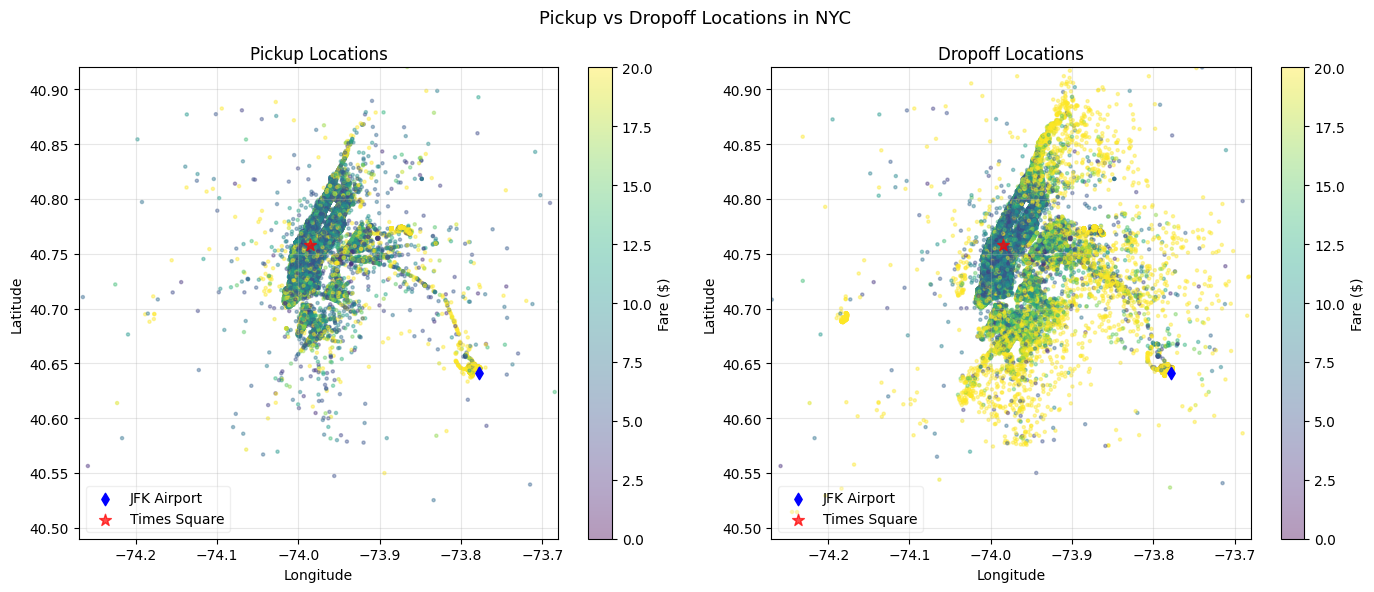

In [20]:
fig,axes = plt.subplots(1,2,figsize=(14, 6))
# Pickup
p1 = axes[0].scatter(train["pickup_longitude"],train["pickup_latitude"],s=5,c=train["fare_amount"],
                        vmin=0,vmax=20,cmap="viridis",alpha=0.4)
axes[0].set_title('Pickup Locations')
plt.colorbar(p1,label='Fare ($)')
# Dropoff
p2 = axes[1].scatter(train["dropoff_longitude"],train["dropoff_latitude"],s=5,c=train["fare_amount"],
                        vmin=0,vmax=20,cmap="viridis",alpha=0.4)
axes[1].set_title("Dropoff Locations")
plt.colorbar(p2,label='Fare ($)')
for ax in axes:
    ax.set_xlim(-74.27,-73.68) # Source Wikipedia
    ax.set_ylim(40.49, 40.92) # Source Wikipedia
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.grid(alpha=0.3)
    ax.scatter(-73.7781, 40.6413, s=40, c='b', marker='d', label='JFK Airport')
    ax.scatter(-73.9855, 40.7580, s=80, c='r', marker='*', label='Times Square',alpha=0.7)
    ax.legend(loc='lower left',framealpha=0.3)
plt.suptitle('Pickup vs Dropoff Locations in NYC',fontsize=13)
plt.tight_layout()
plt.savefig('output/location.png')
plt.show()

- Most Pickup locations are concentrated in central Manhattan while dropoff locations are more dispersed across all five boroughs.

- The strip pattern in the lower right (~40.65, -73.78) corresponds to JFK Airport terminal roads shows the highest fares ($20+, yellow) due to the fixed flat-rate.

- Co-ordinate outliers which are outisde of NYC geo-loaction are removed.

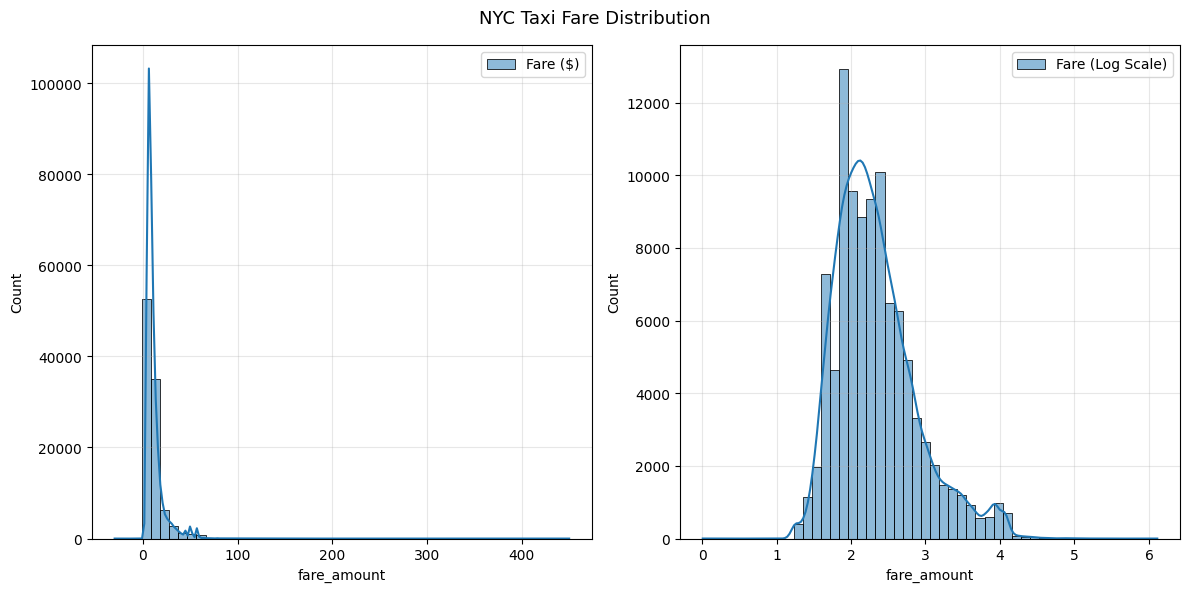

In [21]:
fig,axes = plt.subplots(1,2,figsize=(12,6),sharex=False)
sns.histplot(train["fare_amount"],bins=50,kde=True,ax=axes[0],label='Fare ($)')
sns.histplot(np.log1p(train[train["fare_amount"]>0]["fare_amount"]),bins=50,kde=True,ax=axes[1],
             label='Fare (Log Scale)')
for ax in axes:
    ax.legend()
    ax.grid(alpha=0.3)
plt.suptitle('NYC Taxi Fare Distribution', fontsize=13)
plt.tight_layout()
plt.savefig('output/fare_distribution.png')
plt.show()

- The fare distribution is highly right-skewed due to high-value trips (~$263 etc.,) while the median is much lower (~$8.5). Invalid negative prices in the fare column are removed duing data cleaning. For usage in ensemble modeling and easier interpretion will keep fare column in raw dollar format. 

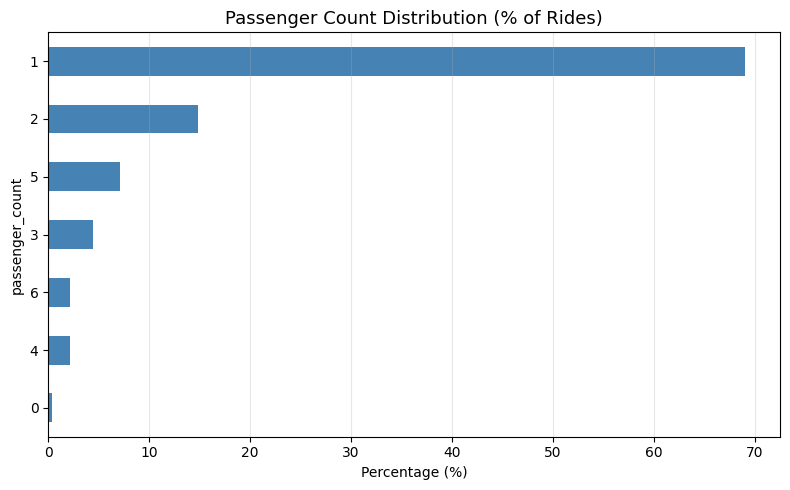

In [22]:
plt.figure(figsize=(8, 5))
train["passenger_count"].value_counts(normalize=True,ascending=True).mul(100).plot(kind="barh",color='steelblue')
plt.title("Passenger Count Distribution (% of Rides)",fontsize=13)
plt.xlabel("Percentage (%)")
plt.grid(alpha=0.3,axis='x')
plt.tight_layout()
plt.savefig('output/passenger_distribution.png')
plt.show()

- 70% of all trips are single passenger, also invalid passenger counts (~0) are removed as data quality issue.

### Data Cleaning

In [23]:
# Data clening function to apply on training and testing dataset
def data_cleaning(df):
    # 1. Creating a clone for reporducibility
    df_clean = df.copy()

    # 2. Removing negative prices
    if "fare_amount" in df_clean.columns:
        df_clean = df_clean[df_clean["fare_amount"]>0]

    # 3. Removing negative passenger count
    if "passenger_count" in df_clean.columns:
        df_clean = df_clean[df_clean["passenger_count"]>0]
    
    # 4. Removing co-ordinate outliers
    for col in df_clean.columns:
        if "longitude" in col:
            df_clean=df_clean[df_clean[col].between(-74.27,-73.68)]
        if "latitude" in col:
            df_clean=df_clean[df_clean[col].between(40.49, 40.92)]

    print (f"Rows removed:{len(df)-len(df_clean)}")
    return  df_clean.reset_index(drop=True) 
    
train_clean = data_cleaning(train)

Rows removed:2565


### Feature Engineering

In [24]:
def add_features(df):

    """
    Haversign_distance:
    2R * arcsin(√[ sin²((lat₂ - lat₁)/2) + cos(lat₁) * cos(lat₂) * sin²((lon₂ - lon₁)/2)])
     where R = 6,371 is mean earth radius in Km, Source wikipedia

    Cyclic Time Features:
    value_sin = sin(2π * value / period)
    value_cos = cos(2π * value / period)
     where period is hour, dayofweek, month
    """
    df_feature =df.copy()
    # cyclic datetime feature 
    df_feature["pickup_datetime"] = pd.to_datetime(df_feature["pickup_datetime"],utc=True).dt.tz_convert("America/New_York")
    df_feature["hour_sin"] = np.sin(2*np.pi*df_feature["pickup_datetime"].dt.hour/24)
    df_feature["hour_cos"] = np.cos(2*np.pi*df_feature["pickup_datetime"].dt.hour/24)
    df_feature["week_sin"] = np.sin(2*np.pi*df_feature["pickup_datetime"].dt.day_of_week/7)
    df_feature["week_cos"] = np.cos(2*np.pi*df_feature["pickup_datetime"].dt.day_of_week/7)
    df_feature["month_sin"] = np.sin(2*np.pi*df_feature["pickup_datetime"].dt.month/12)
    df_feature["month_cos"] = np.cos(2*np.pi*df_feature["pickup_datetime"].dt.month/12)
    df_feature["year"] = df_feature["pickup_datetime"].dt.year
    
    # haversign_distance
    lat1=np.radians(df_feature['pickup_latitude'])
    lat2=np.radians(df_feature['dropoff_latitude'])
    lon1=np.radians(df_feature['pickup_longitude'])
    lon2=np.radians(df_feature['dropoff_longitude'])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    df_feature["distance_km"] = 2*6371*(np.arcsin((np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2)**(0.5)))


    print(f"Features added, Shape: {df_feature.shape}")
    return df_feature
train_clean = add_features(train_clean)

Features added, Shape: (97435, 16)


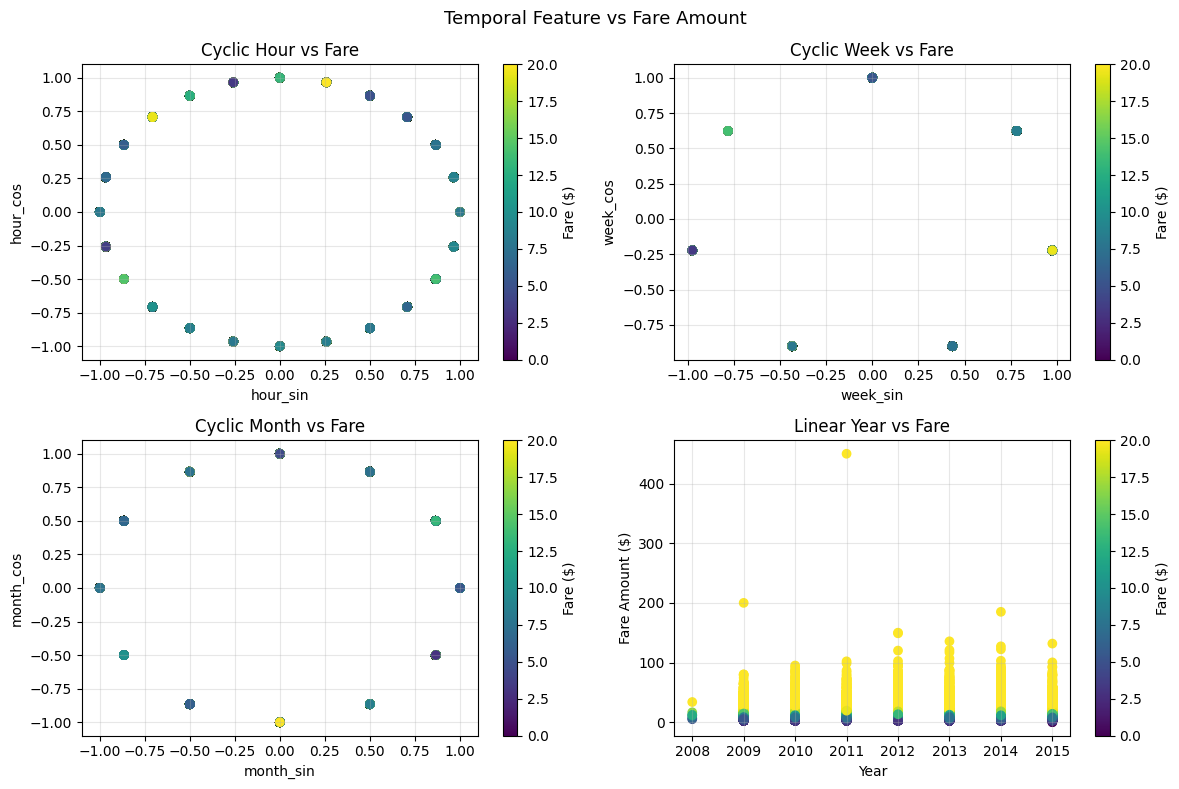

In [25]:
fig,axes = plt.subplots(2,2,figsize=(12,8))
# Hour
p1 = axes[0,0].scatter(train_clean["hour_sin"],train_clean["hour_cos"],c= train_clean["fare_amount"],cmap="viridis",vmin=0,vmax=20)
axes[0, 0].set_xlabel('hour_sin')
axes[0, 0].set_ylabel('hour_cos')
axes[0,0].set_title('Cyclic Hour vs Fare')
plt.colorbar(p1, ax=axes[0,0], label='Fare ($)')
# Week
p2 = axes[0,1].scatter(train_clean["week_sin"],train_clean["week_cos"],c= train_clean["fare_amount"],cmap="viridis",vmin=0,vmax=20)
axes[0, 1].set_xlabel('week_sin')
axes[0, 1].set_ylabel('week_cos')
axes[0,1].set_title('Cyclic Week vs Fare')
plt.colorbar(p2, ax=axes[0,1], label='Fare ($)')
# Month
p3 = axes[1,0].scatter(train_clean["month_sin"],train_clean["month_cos"],c= train_clean["fare_amount"],cmap="viridis",vmin=0,vmax=20)
axes[1, 0].set_xlabel('month_sin')
axes[1, 0].set_ylabel('month_cos')
axes[1,0].set_title('Cyclic Month vs Fare')
plt.colorbar(p3, ax=axes[1,0], label='Fare ($)')
# Year
p4 = axes[1,1].scatter(train_clean["year"],train_clean["fare_amount"],c= train_clean["fare_amount"],cmap="viridis",vmin=0,vmax=20)
axes[1, 1].set_xlabel('Year')
axes[1, 1].set_ylabel('Fare Amount ($)')
axes[1,1].set_title('Linear Year vs Fare')
plt.colorbar(p4, ax=axes[1,1], label='Fare ($)')
# Grid
for ax in axes.flatten():
    ax.grid(alpha=0.3)
plt.suptitle('Temporal Feature vs Fare Amount', fontsize=13)
plt.tight_layout()
plt.savefig('output/temoral_feature.png')
plt.show()

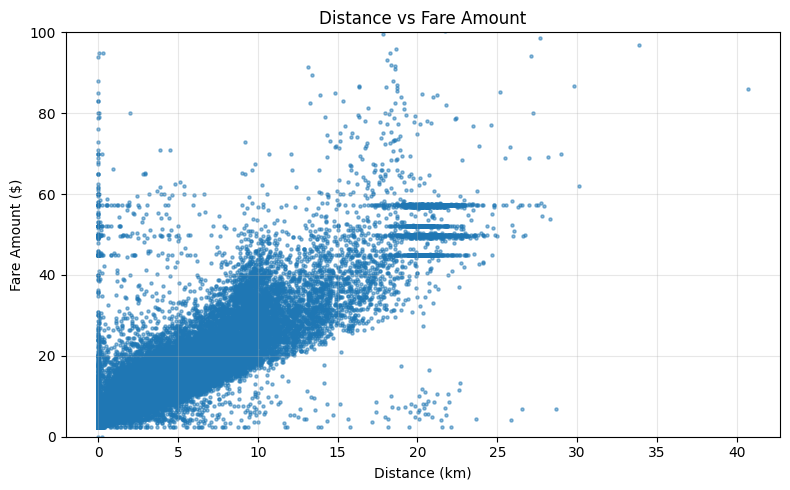

In [26]:
plt.figure(figsize=(8, 5))
plt.scatter(train_clean['distance_km'], train_clean['fare_amount'],s=5,alpha=0.5)
plt.ylim(0,100)
plt.xlabel('Distance (km)')
plt.ylabel('Fare Amount ($)')
plt.title('Distance vs Fare Amount')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('output/distance_vs_fare.png')
plt.show()

- Fare increases with distance but flat-line cluster present near $40-60 range indicating non-linear relationship between fare and distance. Will use tree based model(~brgging and boosting).

### Ensemble Models

In [27]:
# 1. Sort by datetime for time based train-test split
train_clean = train_clean.sort_values(by=["pickup_datetime"])

# 2. Feature and target
X = train_clean.drop(['key','fare_amount','pickup_datetime'],axis = 1)
# Ignoring log transformation for interpretability
y =  train_clean["fare_amount"]

# 3. Split into train (90%) and test (10%)
split_index = int(len(X) * 0.9)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

# 4. Model comparison
models = {"RandomForest": RandomForestRegressor(criterion="squared_error",n_estimators=100,
                                                max_depth=6,n_jobs=-1,random_state=42),
          "XGBoost":          XGBRegressor(objective="reg:squarederror",n_estimators=100,
                                       max_depth=6,eval_metric="rmse",n_jobs=-1,random_state=42)}
results = {} 

for name, model in models.items():
    model.fit(X_train,y_train)

    # Training set prediction
    y_train_pred = model.predict(X_train)
    train_rmse = root_mean_squared_error(y_train,y_train_pred)

    # Cross validation with kfold=5
    kf = KFold(n_splits=5, shuffle=False) # Shuffle = False to prevent data leakage
    cv = cross_val_score(estimator= model, X=X_train, y= y_train, scoring="neg_root_mean_squared_error",cv=kf)
    cv_rmse = -cv.mean()

    # Test set prediction
    y_test_pred = model.predict(X_test)
    test_rmse = root_mean_squared_error(y_test,y_test_pred)

    # Evaluation
    results[name] = {
        "Train RMSE":    train_rmse,
        "CV RMSE":       cv_rmse,
        "Test RMSE":     test_rmse,
        "Overfit (train-CV)":   abs(train_rmse-cv_rmse)
    }
evaluation = pd.DataFrame(results).round(2)
print("="*50)
print("Baseline Models Comparison")
print("="*50)
display(evaluation)  


Baseline Models Comparison


,RandomForest,XGBoost
Train RMSE,4.20,2.68
CV RMSE,4.45,4.33
Test RMSE,3.80,3.49
Overfit (train-CV),0.25,1.66


Using chronological train-test split to prevent temporal data leakage, the baseline models under same stopping condition (`max_depth`= 6,`n_estimators`=100), demonstrate the following performance:

  - Best Model: XGB has lower test RMSE ($3.53 vs $3.80).

  - Overfit: XGBoost shows a larger train-CV gap (1.63). Need hyperparameter tuning to reduce model complexity (variance).

  - Generalization: Both model generalize well as test RMSE close to CV RMSE.
   

### Hyperparemeter tuninng of XGboost

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters: {'subsample': 0.7, 'reg_alpha': 0.5, 'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 0.8}


,RandomForest,XGBoost,XGBoost_tuned
Train RMSE,4.20,2.68,3.78
CV RMSE,4.45,4.33,4.25
Test RMSE,3.80,3.49,3.55
Overfit (train-CV),0.25,1.66,0.48


<Figure size 800x500 with 0 Axes>

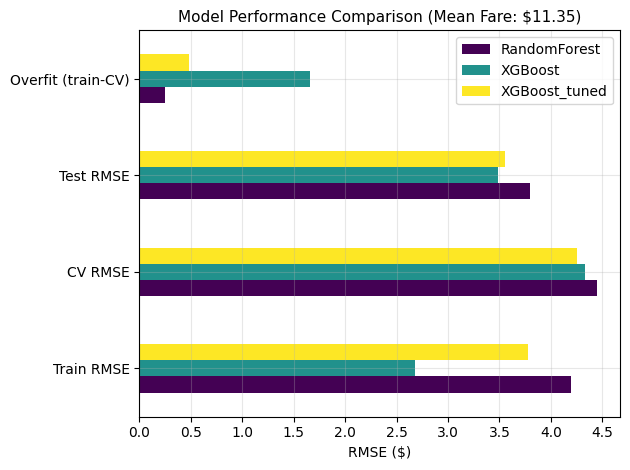

In [28]:
xgb = XGBRegressor(objective="reg:squarederror",eval_metric="rmse",n_jobs=-1,random_state=42)
param_gid = {
    "n_estimators":      [100,200,300], # Number of trees
    'max_depth' :        [4,5],     # Maximum depth in each tree
    "learning_rate":     [0.03,0.05], # Step size for each tree
    "subsample":         [0.7,0.8],   # Fraction of training data used per tree
    "colsample_bytree":  [0.7, 0.8], # Fraction of feature used per tree
    "reg_alpha":         [0.5,1], # L1 Regularization
    }
xgb_gridcv = RandomizedSearchCV(xgb,param_gid,scoring="neg_root_mean_squared_error",
                          n_jobs=-1,verbose=1, cv=KFold(n_splits=5, shuffle=False),random_state=42)
xgb_gridcv.fit(X_train,y_train)

# Evaluation
y_train_pred_tuned = xgb_gridcv.best_estimator_.predict(X_train)
y_test_pred_tuned =  xgb_gridcv.best_estimator_.predict(X_test)
train_rmse_tuned =   root_mean_squared_error(y_train,y_train_pred_tuned)
cv_rmse_tuned =     -xgb_gridcv.best_score_
test_rmse_tuned =    root_mean_squared_error(y_test,y_test_pred_tuned)
evaluation["XGBoost_tuned"] = pd.Series({
        "Train RMSE":    train_rmse_tuned,
        "CV RMSE":       cv_rmse_tuned,
        "Test RMSE":     test_rmse_tuned,
        "Overfit (train-CV)":   abs(train_rmse_tuned-cv_rmse_tuned)
    }).round(2)
print("="*80)
print(f"Best Parameters: {xgb_gridcv.best_params_}")
print("="*80)
display(evaluation)
plt.figure(figsize=(8,5))
evaluation.plot(kind="barh",cmap='viridis')
plt.title(f"Model Performance Comparison (Mean Fare: ${train['fare_amount'].mean():.2f})",fontsize=11)
plt.xlabel("RMSE ($)")
plt.xticks(np.arange(0,5,0.5))
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('output/model_comparison.png')
plt.show()  


- Reduced the overfitting gap from $1.66 to $0.48 while maintaining low Test RMSE ($3.55) - achived by regularizing with learning rate, L1 penalization and subsampling of data.

<Figure size 800x500 with 0 Axes>

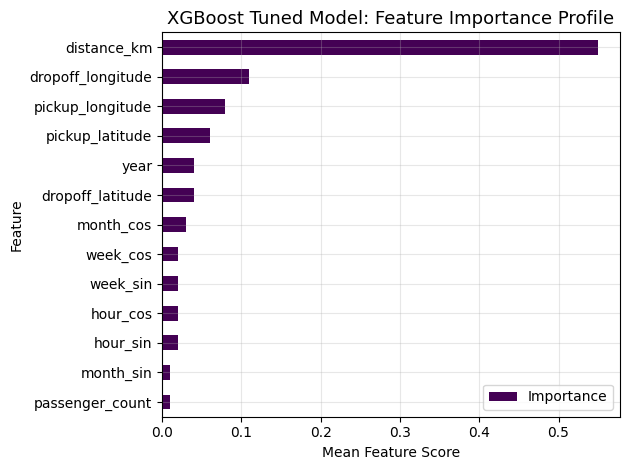

In [29]:
importance = pd.DataFrame({"Feature":xgb_gridcv.best_estimator_.feature_names_in_,
                               "Importance":xgb_gridcv.best_estimator_.feature_importances_})
importance = importance.round(2).sort_values("Importance",ascending=True).set_index("Feature")
plt.figure(figsize=(8,5))
importance.plot(kind="barh",cmap="viridis")
plt.title("XGBoost Tuned Model: Feature Importance Profile", fontsize=13)
plt.xlabel("Mean Feature Score")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('output/feature_imortance.png')
plt.show()


- Fare is primarily distance driven, validataing feature engineering of haversign distance.

- Pickup and dropoff longitudes consistently rank higher in importance than latitudes - confirming airport trips (East-West corridor in this city) capture most fare variance.

- Passenger count has lowest importnce, confirmieng NYC taxi fare follow flat rate pricing not per passenger.

- Year feature capture fare inflation over then year.

In [30]:
print("Notebook Run Successfully!")


Notebook Run Successfully!
